NOTES:
- imputation before transformation before scaling


## Load packages

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import sklearn

# downloading and managing paths
import tarfile
import urllib.request
from pathlib import Path

# visualization modules
import matplotlib.pyplot as plt
import seaborn as sns

# for printing nicely
from pprint import pprint 

# ensure the python runtime is higher than 3.7
assert sys.version_info >= (3, 7)

## Load data

In [ ]:
# data fetching function
def load_housing_data():
    # download the data if not present
    data_path = Path("data/housing/housing.csv")
    if not data_path.is_file():
        print("Trying to extract dataset")
        tarball_path = Path("data/housing.tgz")
        if not tarball_path.is_file():
            print("File does not exist, downloading...")
            Path("data").mkdir(parents=True, exist_ok=True)
            url = "https://github.com/ageron/data/raw/main/housing.tgz"
            urllib.request.urlretrieve(url, tarball_path)
            with tarfile.open(tarball_path) as housing_tarball:
                print("Extracting files...")
                # housing_tarball.extractall(path="data")
                housing_tarball.extractall(path="data/housing/")
                print("Dataset extracted.")
    # define data path
    data_path = Path("data/housing/housing.csv")
    # data_path = Path("data/housing/housing.csv")
    
    return pd.read_csv(data_path, skipinitialspace=True)

# load dataset
housing = load_housing_data()


## Data overview and cleaning

In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Data spliting
- Use target variable if classification
- Use meaningful highly correlated feature if regression
- One can also use meaningful categorical feature if regression

In [8]:
# get correlation of numeric values
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [9]:
# get the statistics of the highly correlated feature
housing["median_income"].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

In [10]:
# bin the highly correlated feature (median_income)
housing["income_category"] = pd.cut(housing["median_income"],
                                    bins=4, labels=range(4))

housing["income_category"].value_counts()

income_category
0    13167
1     6665
2      674
3      134
Name: count, dtype: int64

In [11]:
# split data using the income categories
from sklearn.model_selection import train_test_split

housing_train, housing_test = train_test_split(housing, test_size=0.2,
                                               stratify=housing["income_category"],
                                               shuffle=True, random_state=42)


In [12]:
# get the distribution of the income categories in train set
housing_train["income_category"].value_counts()

income_category
0    10534
1     5332
2      539
3      107
Name: count, dtype: int64

In [13]:
# get the distribution of the income categories in test set
housing_test["income_category"].value_counts()

income_category
0    2633
1    1333
2     135
3      27
Name: count, dtype: int64

In [14]:
# drop income category
if "income_category" in housing_train.columns:
    housing_train = housing_train.drop(columns=["income_category"])
    housing_test = housing_test.drop(columns=["income_category"])

housing_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14552,-122.35,40.68,36.0,1822.0,449.0,930.0,399.0,1.3801,56600.0,INLAND
19598,-118.37,34.12,34.0,2821.0,399.0,843.0,391.0,11.6150,500001.0,<1H OCEAN
19602,-121.90,38.03,51.0,2982.0,689.0,1831.0,608.0,2.0034,87700.0,INLAND
17870,-118.48,34.19,20.0,5699.0,1594.0,3809.0,1381.0,2.8646,221100.0,<1H OCEAN
8483,-117.94,34.04,36.0,1431.0,354.0,1367.0,334.0,3.5592,160200.0,<1H OCEAN


## Data Exploration

In [15]:
# let's recall what the training data looks like
housing_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14552,-122.35,40.68,36.0,1822.0,449.0,930.0,399.0,1.3801,56600.0,INLAND
19598,-118.37,34.12,34.0,2821.0,399.0,843.0,391.0,11.6150,500001.0,<1H OCEAN
19602,-121.90,38.03,51.0,2982.0,689.0,1831.0,608.0,2.0034,87700.0,INLAND
17870,-118.48,34.19,20.0,5699.0,1594.0,3809.0,1381.0,2.8646,221100.0,<1H OCEAN
8483,-117.94,34.04,36.0,1431.0,354.0,1367.0,334.0,3.5592,160200.0,<1H OCEAN


In [16]:
housing_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14552 to 16045
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16355 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.4+ MB


In [17]:
# separate variables, features and target types
# the target variable is included in the NUM_VARS as it is a numerical variable
NUM_VARS = housing_train.select_dtypes(include=["float64"]).columns.tolist()
CAT_VARS = housing_train.select_dtypes(include=["object"]).columns.tolist()

LABEL = ["median_house_value"]
NUM_FEATURES = [NUM_FEAT for NUM_FEAT in NUM_VARS if NUM_FEAT != LABEL[0]]
CAT_FEATURES = [CAT_FEAT for CAT_FEAT in CAT_VARS if CAT_FEAT != LABEL[0]]

print("CATEGORICAL VARIABLES:", CAT_VARS)
print("NUMERICAL VARIABLES", NUM_VARS)

print("CATEGORICAL FEATURES:", CAT_FEATURES)
print("NUMERICAL FEATURES:", NUM_FEATURES)

print("LABEL:", LABEL)

CATEGORICAL VARIABLES: ['ocean_proximity']
NUMERICAL VARIABLES ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
CATEGORICAL FEATURES: ['ocean_proximity']
NUMERICAL FEATURES: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
LABEL: ['median_house_value']


Univariate analysis
- numerical

In [18]:
# statistic of numerical variables
housing_train.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16355.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.573914,35.634229,28.626332,2637.662427,538.932131,1429.435986,500.523922,3.870582,206719.838299
std,2.000135,2.130673,12.641966,2207.950597,425.907924,1151.303416,387.102822,1.902195,115111.663990
min,-124.300000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.940000,18.000000,1445.000000,295.000000,789.000000,279.000000,2.562500,120000.000000
50%,-118.500000,34.260000,29.000000,2125.000000,433.000000,1164.000000,408.000000,3.531750,179800.000000
75%,-118.010000,37.710000,37.000000,3144.250000,648.000000,1728.000000,605.000000,4.734700,263900.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


<Axes: >

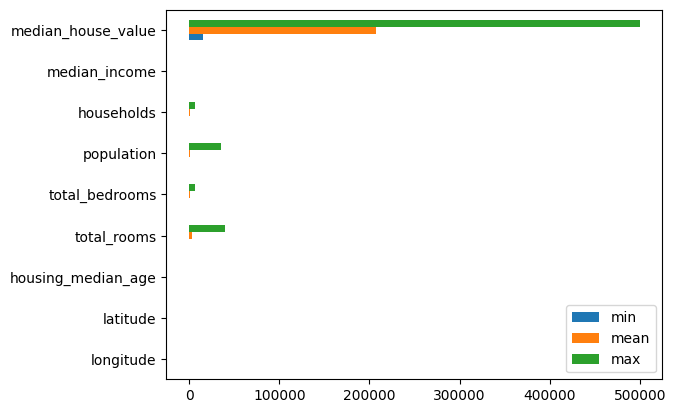

In [19]:
# range values of the numerical features
housing_train.describe().transpose()[["min", "mean", "max"]].plot(kind="barh")

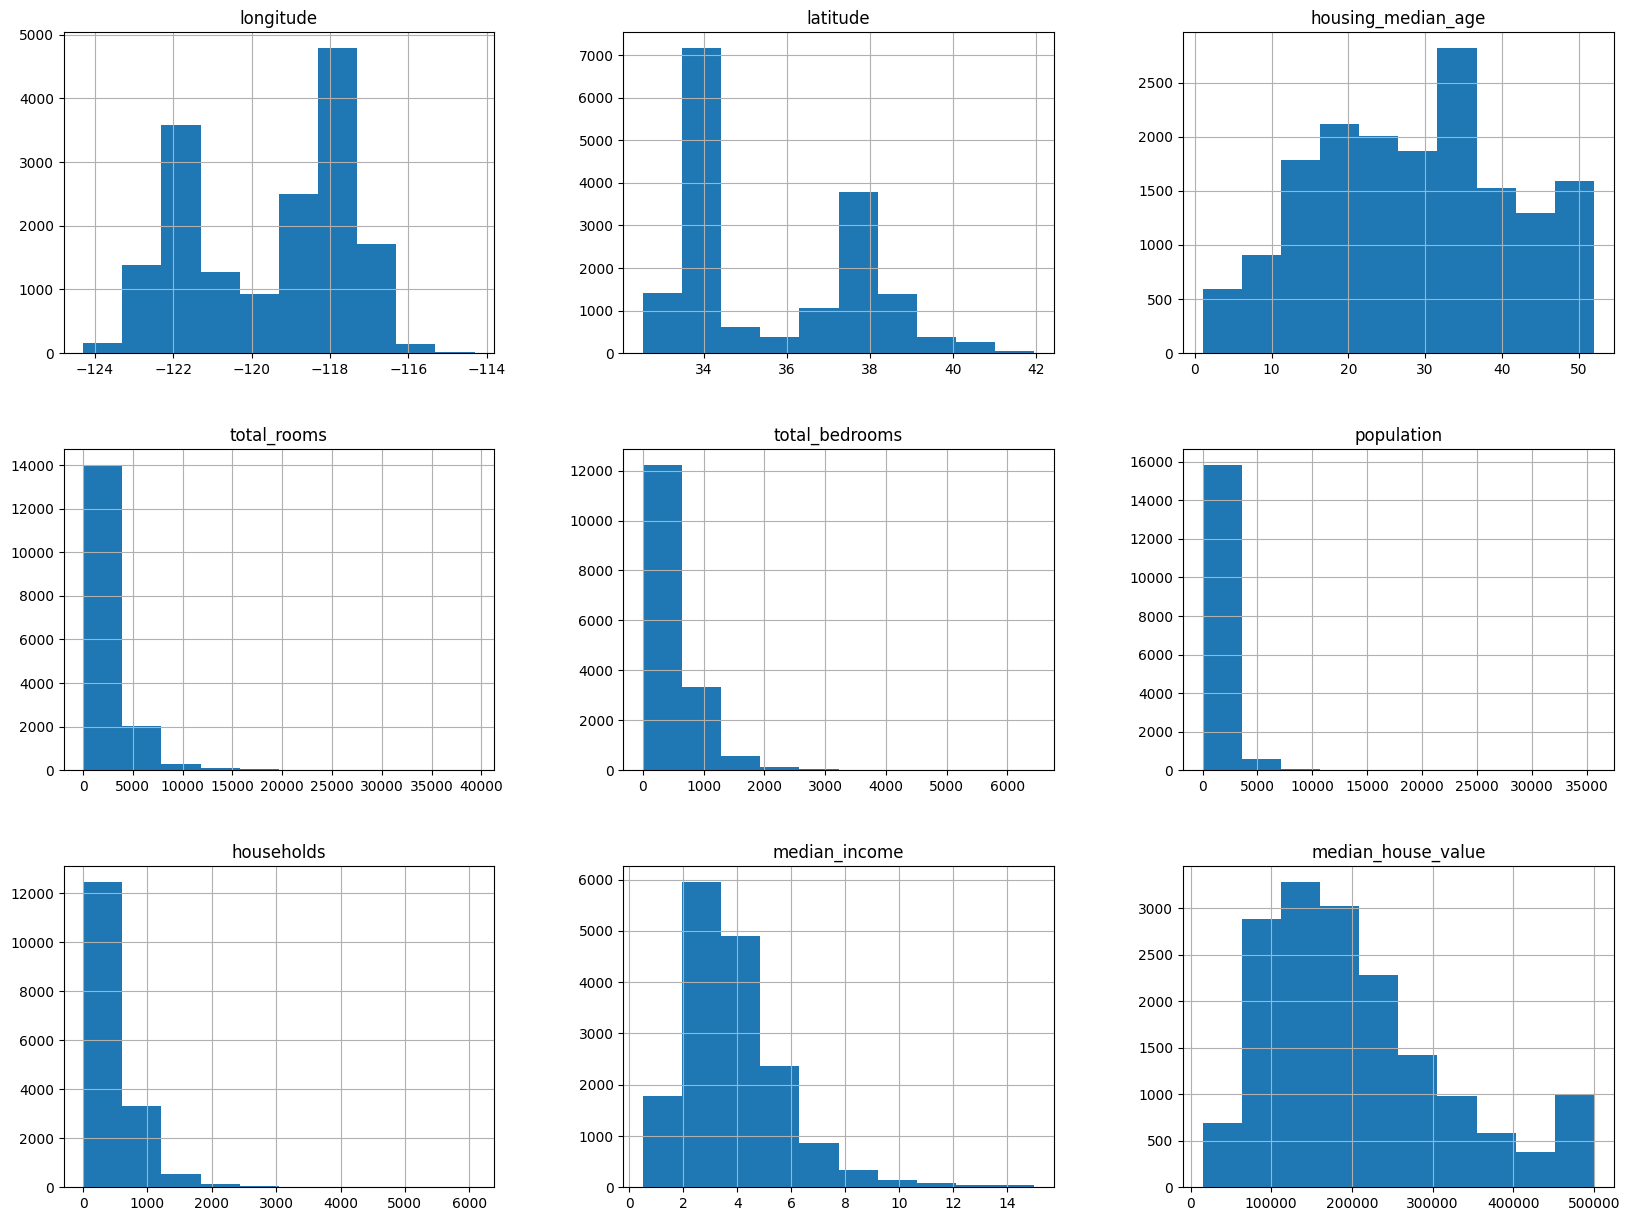

In [20]:
# numerical variables distribution
housing_train[NUM_VARS].hist(figsize=(20, 15))
plt.show()

Insights
- the numerical variables are on different scale, data should be scaled.
- total_rooms, total_bedrooms, population, households, and median_income are right skewed.

- categorical

In [21]:
# get categorical variables statistics
housing_train[CAT_VARS].describe()

,ocean_proximity
count,16512
unique,5
top,<1H OCEAN
freq,7301


In [22]:
# categorical variables distributions
housing_train[CAT_VARS].value_counts()

ocean_proximity
<1H OCEAN          7301
INLAND             5232
NEAR OCEAN         2128
NEAR BAY           1849
ISLAND                2
Name: count, dtype: int64

<Axes: xlabel='OCEAN PROXIMITY', ylabel='NUMBER OF DISTRICTS'>

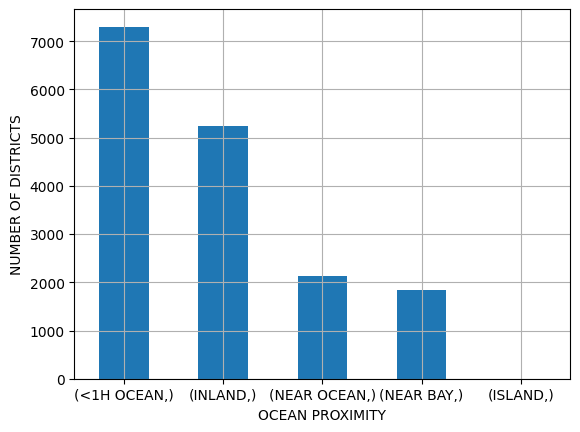

In [23]:
housing_train[CAT_VARS].value_counts().plot(kind="bar", rot=0, grid=True,
                                            xlabel="OCEAN PROXIMITY",
                                            ylabel="NUMBER OF DISTRICTS")

Insights
- island is not well represented with only two observations

Bivariate

<Axes: >

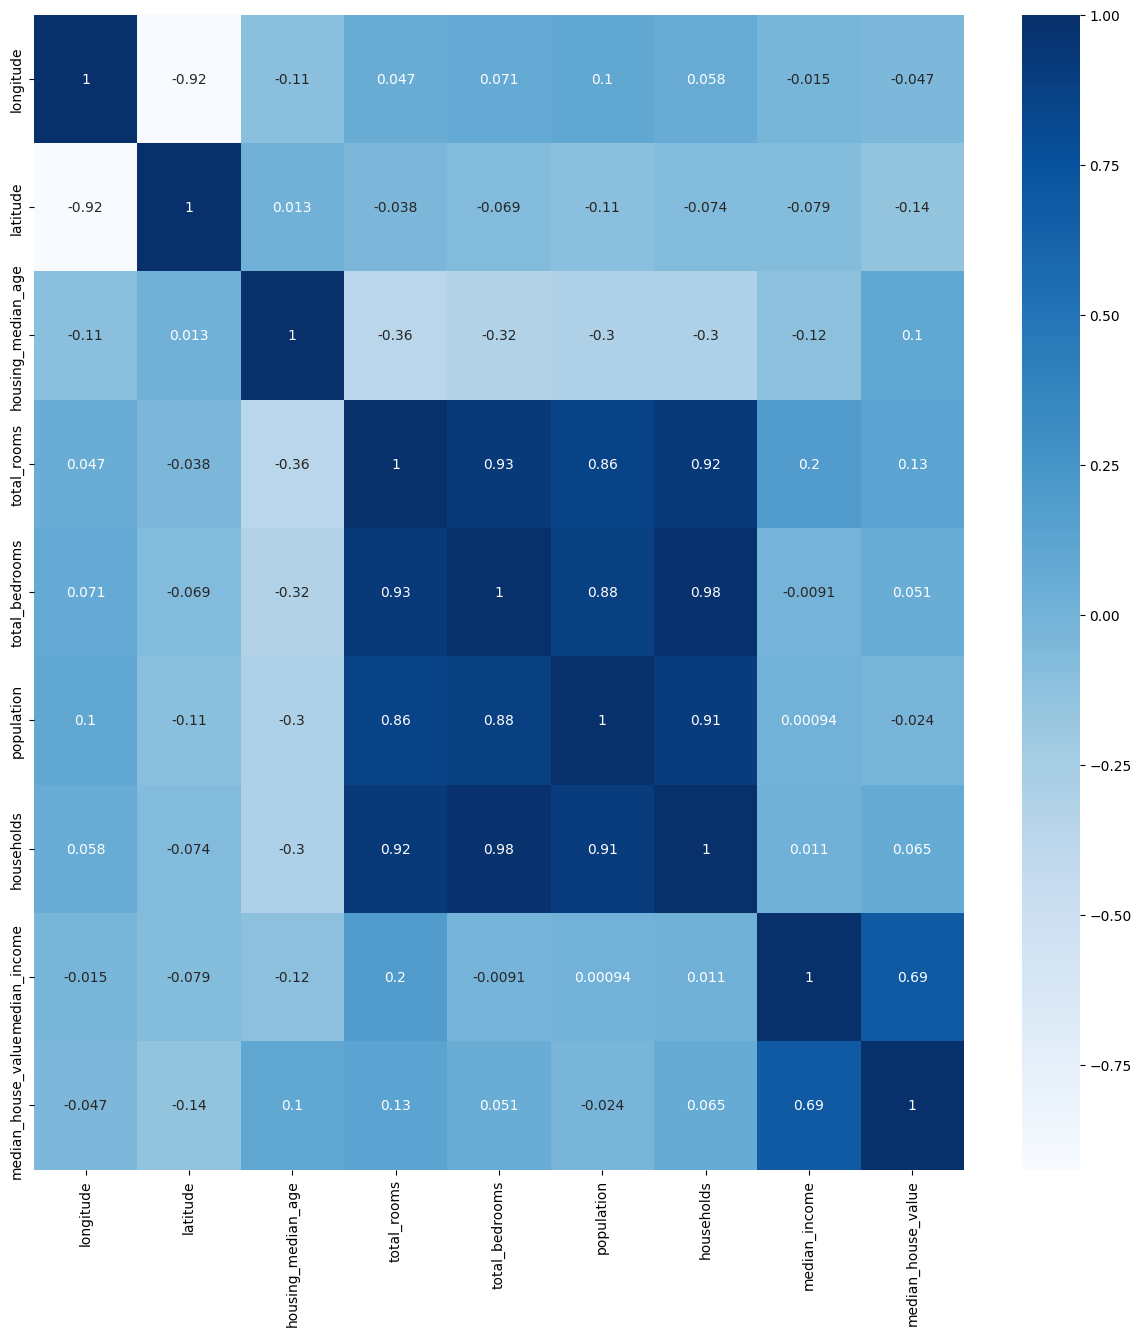

In [24]:
corr_matrix = housing_train[NUM_VARS].corr()
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap="Blues",)

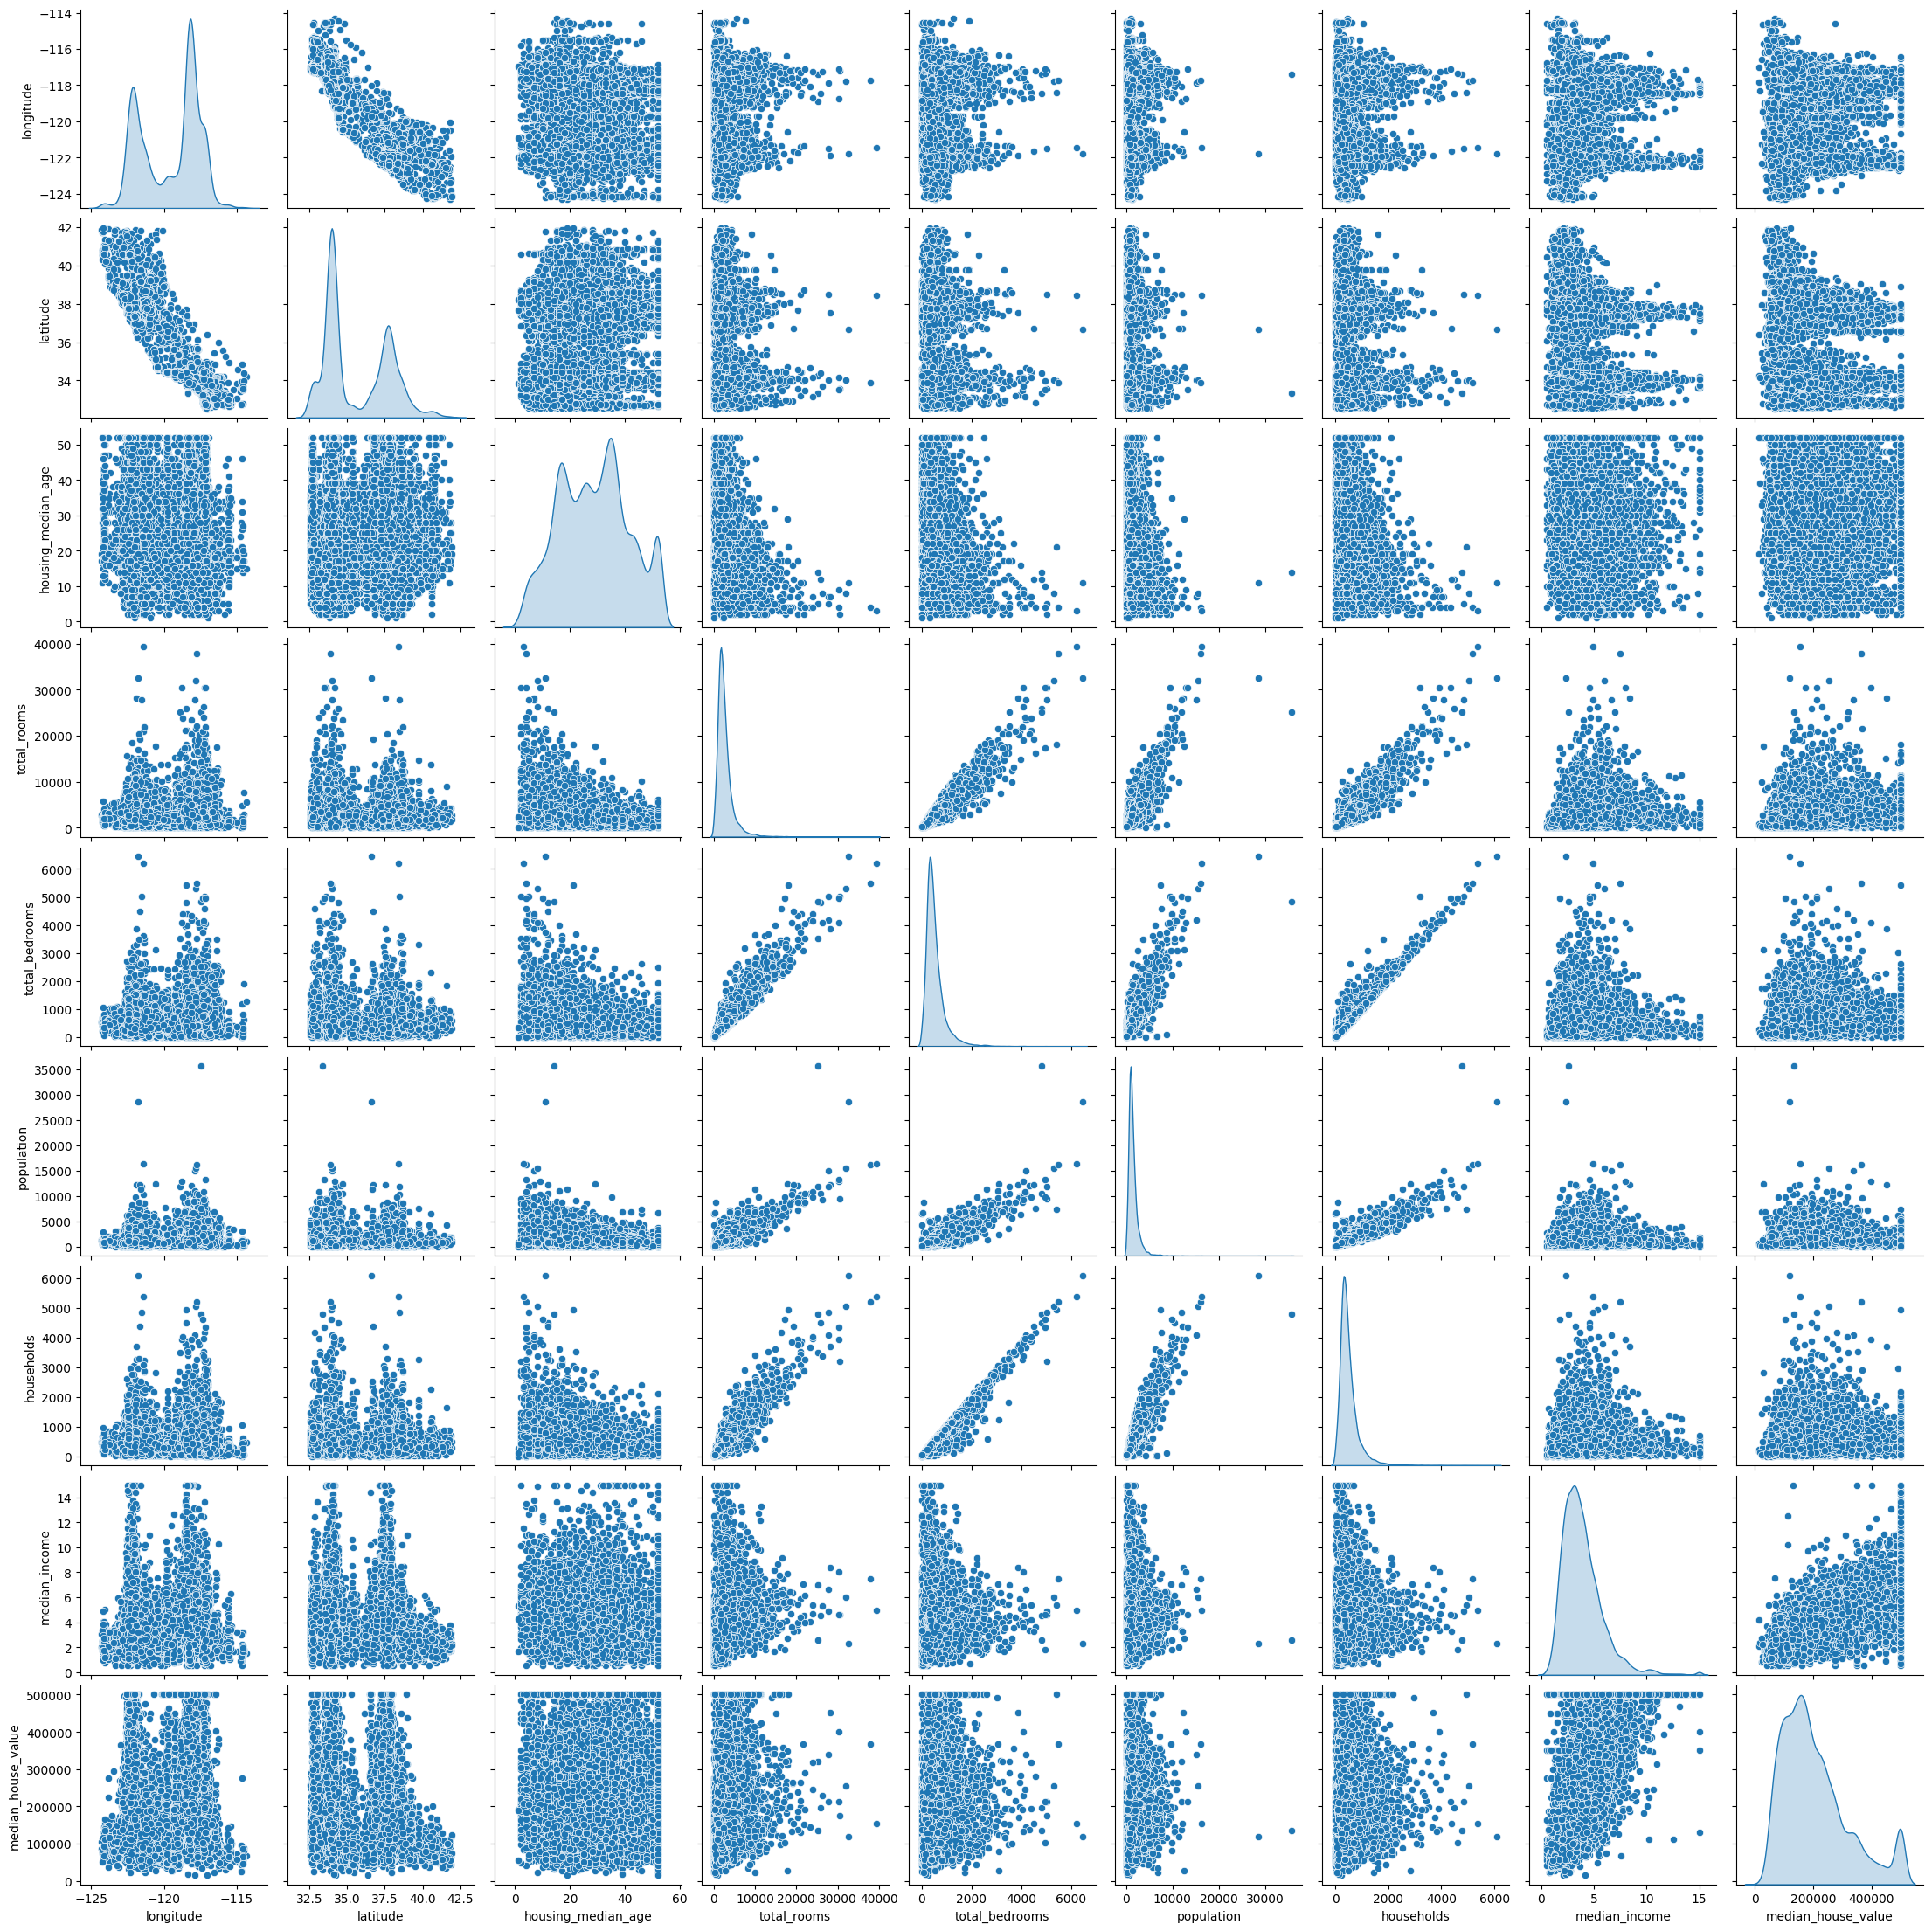

In [25]:
sns.pairplot(housing_train[NUM_VARS], diag_kind="kde")
plt.show()

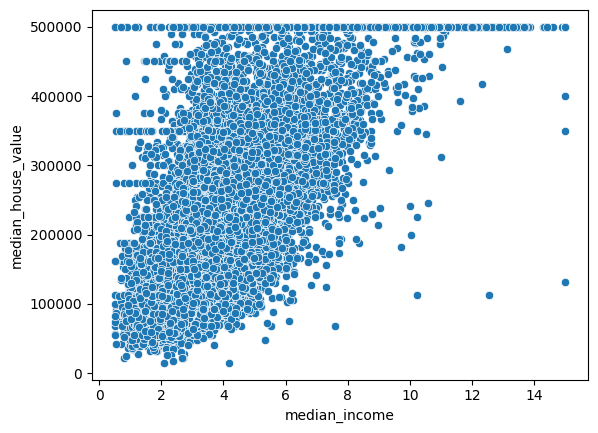

In [26]:
# the highly correlated features with the target variable
sns.scatterplot(data=housing_train, x="median_income", y=LABEL[0])
plt.show()

In [27]:
housing_train.groupby(by=CAT_VARS[0])["median_house_value"].describe()

,count,mean,std,min,25%,50%,75%,max
ocean_proximity,,,,,,,,
<1H OCEAN,7301.0,239223.258595,105367.846106,17500.0,163400.0,214900.0,287500.0,500001.0
INLAND,5232.0,124804.877676,69157.758134,14999.0,77800.0,109400.0,150000.0,500001.0
ISLAND,2.0,375000.000000,106066.017178,300000.0,337500.0,375000.0,412500.0,450000.0
NEAR BAY,1849.0,258866.230936,123559.824281,22500.0,162500.0,234400.0,346100.0,500001.0
NEAR OCEAN,2128.0,251135.421992,123398.899988,28300.0,150000.0,231950.0,326700.0,500001.0


<Axes: xlabel='OCEAN PROXIMITY', ylabel='AVERAGE MEDIAN HOUSE VALUE'>

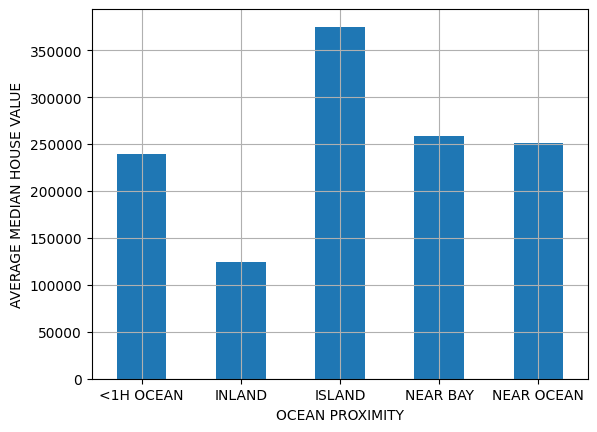

In [28]:
housing_train.groupby(by=CAT_VARS[0])["median_house_value"].describe()["mean"]\
    .plot(kind="bar", rot=0, grid=True, xlabel="OCEAN PROXIMITY", ylabel="AVERAGE MEDIAN HOUSE VALUE")

Insights
- variables like total_rooms, total_bedrooms, population and households are highly correlated with one another, some features may be dropped if doing feature selection.
- median_house_value (target variable seems to be capped)
- people staying on the island seems to pay significantly higher price compared to other locations. Note that this could be biased as there are only few observations for this category, and statistics are better calculated with large observations (law of large numbers).

Multivariate

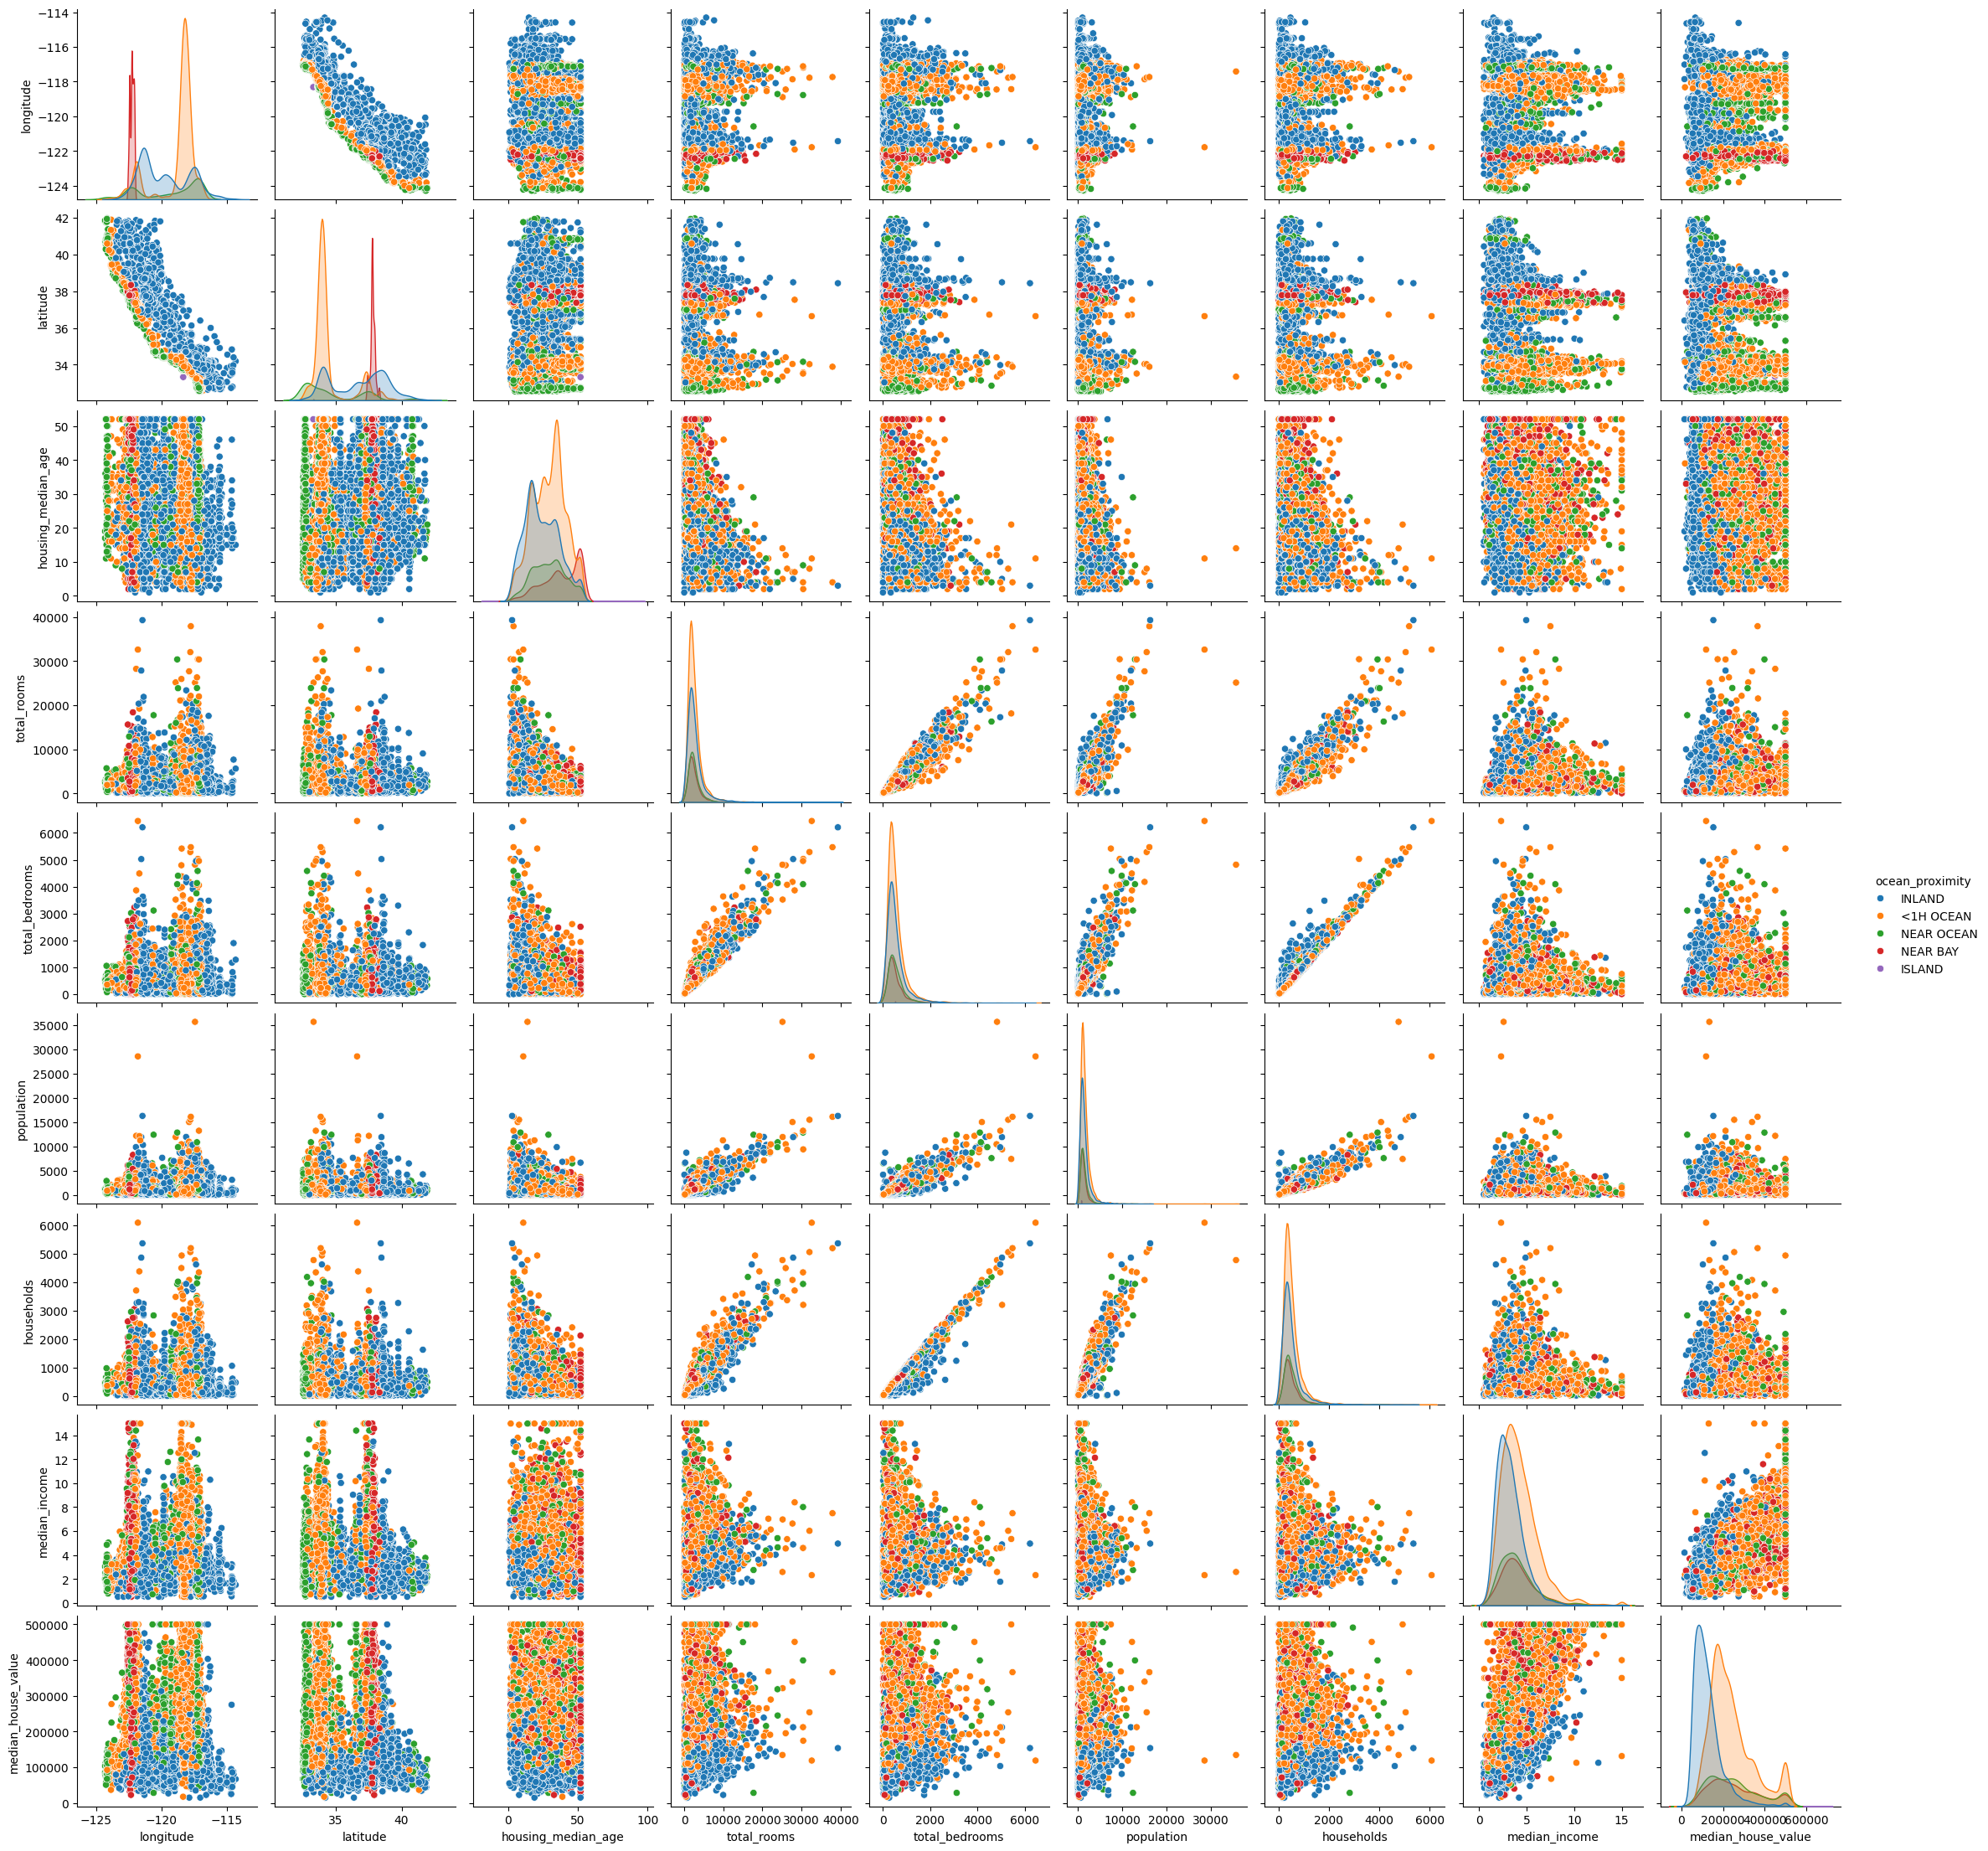

In [29]:
sns.pairplot(housing_train, hue="ocean_proximity")
plt.show()

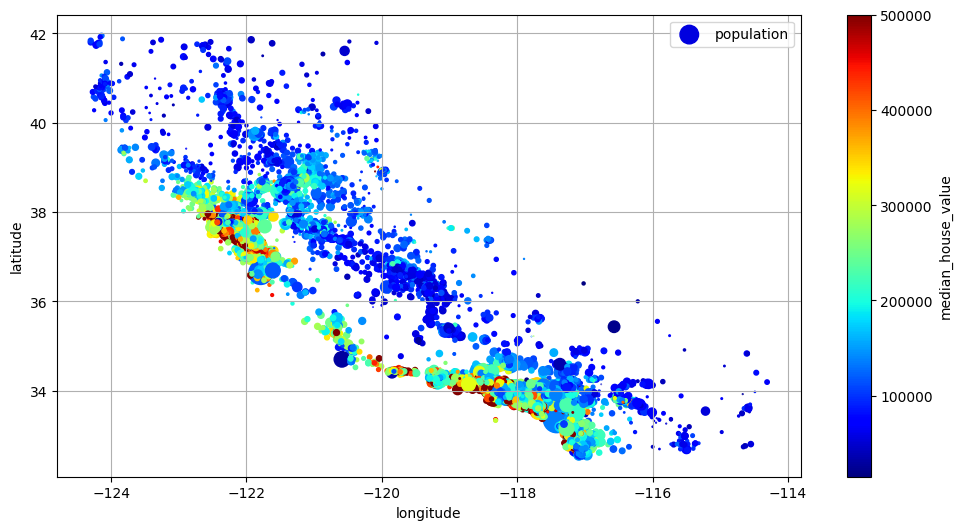

In [30]:
# visualizing geographic data
housing_train.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing_train["population"]/100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(12, 6))
plt.show()

Insights
- most expensive houses are located at the left hand-side boundary

## Data Preprocessing
Two important concepts in data preprocessing are:
- column transformation: allows flexible transformation of feature(s) using appropriate transformer pipe
- transformation pipeline: stringing together all column transformers to generate the final processing pipeline

### Column Transformations
- All transformations are done on the features, and thus label should be dropped, which isn't here
- There are three approaches to transformation
  - Built-in transformers e.g. StandardScaler, SimpleImputer, etc.
  - Using FunctionTransformer Class
  - Creating custom transformer class by inheriting BaseEstimator and TransformerMixin

In [31]:
# separate the features and labels
train_features = housing_train[NUM_FEATURES + CAT_VARS]
train_labels = housing_train[LABEL]

test_features = housing_test[NUM_FEATURES + CAT_VARS]
test_labels = housing_test[LABEL]

In [32]:
train_features

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14552,-122.35,40.68,36.0,1822.0,449.0,930.0,399.0,1.3801,INLAND
19598,-118.37,34.12,34.0,2821.0,399.0,843.0,391.0,11.6150,<1H OCEAN
19602,-121.90,38.03,51.0,2982.0,689.0,1831.0,608.0,2.0034,INLAND
17870,-118.48,34.19,20.0,5699.0,1594.0,3809.0,1381.0,2.8646,<1H OCEAN
8483,-117.94,34.04,36.0,1431.0,354.0,1367.0,334.0,3.5592,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
16866,-121.99,37.36,32.0,1754.0,324.0,917.0,330.0,4.6761,<1H OCEAN
5260,-122.43,37.77,52.0,2685.0,629.0,1170.0,614.0,3.6894,NEAR BAY
5187,-118.26,33.90,22.0,894.0,232.0,754.0,222.0,2.0096,<1H OCEAN
5744,-121.16,37.73,7.0,4956.0,941.0,3006.0,915.0,3.4426,INLAND


In [33]:
# location cluster similarity transformation class
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
	def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
		self.n_clusters = n_clusters
		self.gamma = gamma
		self.random_state = random_state

	def fit(self, X, y=None, sample_weight=None):
		self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)
		self.kmeans_.fit(X, sample_weight=sample_weight)
		return self
	
	def transform(self, X):
		return rbf_kernel(X=X, Y=self.kmeans_.cluster_centers_, gamma=self.gamma)
	
	def get_feature_names_out(self, names=None):
		return [f"Cluster {i}" for i in range(self.n_clusters)]

# sample usage
location_cluster = ClusterSimilarity(n_clusters=5, random_state=43)
location_cluster.fit(train_features[["latitude", "longitude"]], sample_weight=housing_train["median_house_value"])
loc_cluster = location_cluster.transform(train_features[["latitude", "longitude"]])
loc_cluster = pd.DataFrame(data=loc_cluster, columns=location_cluster.get_feature_names_out())
loc_cluster


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
0,8.804381e-05,1.118458e-27,3.606771e-02,3.567066e-38,5.968721e-15
1,3.775507e-12,9.497948e-01,1.234459e-15,5.761364e-02,1.594104e-02
2,8.195312e-01,8.390452e-14,3.131500e-01,1.147693e-21,2.775040e-05
3,1.380888e-11,8.801251e-01,4.860304e-15,3.658674e-02,2.633063e-02
4,7.153628e-14,9.426014e-01,3.030011e-17,1.730296e-01,3.009543e-03
...,...,...,...,...,...
16507,9.153597e-01,6.046439e-12,4.762861e-02,2.435774e-19,3.370174e-04
16508,8.835747e-01,9.340939e-15,8.912404e-02,6.474556e-23,7.863371e-06
16509,3.328866e-13,9.842105e-01,6.619114e-17,1.160234e-01,5.822162e-03
16510,4.052706e-01,1.228298e-10,1.528548e-01,1.540302e-17,1.412669e-03


### Transformation Pipelines

In [34]:
import sklearn.feature_extraction
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

Use compose if subsets of features require different transformations

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

Different transformations on feature subsets

In [36]:
# ratio transformation pipeline
def column_ratio(X):
  return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
  return ["ratio"] # feature names out

def ratio_pipeline():
  return make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(func=column_ratio, feature_names_out=ratio_name),
    StandardScaler()
  )

# log transformation pipeline
log_pipeline = make_pipeline(
  SimpleImputer(strategy="median"),
  FunctionTransformer(np.log, feature_names_out="one-to-one"),
  StandardScaler()
)

# cluster similarity pipeline
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=43)

# default pipeline (simple imputer and scaler features)
default_num_pipeline = make_pipeline(
  SimpleImputer(strategy="median"),
  StandardScaler()
)

# cat pipeline
cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"),
                             OneHotEncoder(handle_unknown="ignore"))


# combine all transformation pipelines
preprocessing = ColumnTransformer([
  ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
  ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
  ("people_per_house", ratio_pipeline(), ["population", "households"]),
  ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                         "households", "median_income"]),
  ("geo", cluster_simil, ["latitude", "longitude"]),
  ("cat", cat_pipeline, make_column_selector(dtype_include=object))
],
remainder=default_num_pipeline) # one column remaining: housing_median_age

# apply preprocessing transformer
Xtrain = preprocessing.fit_transform(train_features)
Xtrain = pd.DataFrame(Xtrain, columns=preprocessing.get_feature_names_out())
Xtrain.shape

(16512, 24)

In [37]:
Xtrain.head(2)

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Cluster 0,geo__Cluster 1,...,geo__Cluster 6,geo__Cluster 7,geo__Cluster 8,geo__Cluster 9,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age
0,0.508370,-0.333835,-0.108956,0.076703,-0.159021,-0.256640,0.011412,-1.958139,2.491157e-05,2.978337e-30,...,1.761015e-18,6.195387e-01,1.375935e-02,5.003620e-27,0.0,1.0,0.0,0.0,0.0,0.583287
1,-1.126381,0.689995,-0.136131,-0.084372,0.421002,-0.389269,-0.016089,2.565031,2.375376e-09,5.588425e-01,...,1.050528e-01,1.388027e-28,2.328035e-14,9.863802e-01,1.0,0.0,0.0,0.0,0.0,0.425079


In [38]:
# transformation pipeline
preprocessing

ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                             SimpleImputer(strategy='median')),
                                            ('standardscaler',
                                             StandardScaler())]),
                  transformers=[('bedrooms',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('functiontransformer',
                                                  FunctionTransformer(feature_names_out=<function ratio_name at 0x0000023146CF04C0>,
                                                                      func=<function column_r...
                                 ['total_bedrooms', 'total_rooms', 'population',
                                  'households', 'median_income']),
                                ('geo', ClusterSimilarity(random_state=43),
                                 ['latitude', 'longitude']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x0000023146CF7850>)])

## Modeling

Get features and labels

In [39]:
Xtrain = preprocessing.fit_transform(train_features)
ytrain = train_labels.copy()

Xtest = preprocessing.transform(test_features)
ytest = test_labels.copy()


Load models and metrics

In [40]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_validate, cross_val_score, cross_val_predict

# load evaluating metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")


##### Cross-validate models

Linear regression

In [41]:
# get cross-validated predictions
cv= 3
pred = cross_val_predict(LinearRegression(), Xtrain, ytrain, cv=cv)

# evaluate model predictions
r2 = np.round(r2_score(pred, ytrain), decimals=3)
rmse = np.round(root_mean_squared_error(pred, ytrain), decimals=3)
mae = np.round(mean_absolute_error(pred, ytrain), decimals=3)

# print metrics
print(f"R2: {r2}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

R2: 0.42
RMSE: 70979.921
MAE: 51225.96


Lasso ( L1-regularization )

In [42]:
# get cross-validated predictions
pred = cross_val_predict(Lasso(), Xtrain, ytrain, cv=cv,)

# evaluate model predictions
r2 = np.round(r2_score(pred, ytrain), decimals=3)
rmse = np.round(root_mean_squared_error(pred, ytrain), decimals=3)
mae = np.round(mean_absolute_error(pred, ytrain), decimals=3)

# print metrics
print(f"R2: {r2}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")


R2: 0.42
RMSE: 70966.006
MAE: 51227.718


Ridge ( L2-regularization)

In [43]:
# get cross-validated predictions
pred = cross_val_predict(Ridge(), Xtrain, ytrain, cv=cv)

# evaluate model predictions
r2 = np.round(r2_score(pred, ytrain), decimals=3)
rmse = np.round(root_mean_squared_error(pred, ytrain), decimals=3)
mae = np.round(mean_absolute_error(pred, ytrain), decimals=3)

# print metrics
print(f"R2: {r2}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

R2: 0.419
RMSE: 70895.54
MAE: 51229.92


Decision tree

In [44]:
# get cross-validated predictions
pred = cross_val_predict(DecisionTreeRegressor(), Xtrain, ytrain, cv=cv)

# evaluate model predictions
r2 = np.round(r2_score(pred, ytrain), decimals=3)
rmse = np.round(root_mean_squared_error(pred, ytrain), decimals=3)
mae = np.round(mean_absolute_error(pred, ytrain), decimals=3)

# print metrics
print(f"R2: {r2}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

R2: 0.643
RMSE: 68886.817
MAE: 43119.868


Random forest

In [45]:
# get cross-validated predictions
pred = cross_val_predict(RandomForestRegressor(random_state=43), Xtrain, ytrain, cv=cv)

# evaluate model predictions
r2 = np.round(r2_score(pred, ytrain), decimals=3)
rmse = np.round(root_mean_squared_error(pred, ytrain), decimals=3)
mae = np.round(mean_absolute_error(pred, ytrain), decimals=3)

# print metrics
print(f"R2: {r2}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

R2: 0.777
RMSE: 48642.191
MAE: 31248.658


Insights:
RandomForest algorithm performs best with significant better metrics of all the algorithms tested, it is therefore worth exploring what one can achieve with hyperparameter search

## Hyperparameter Search

### Grid Searching

In [46]:
from sklearn.model_selection import GridSearchCV

# complete modeling pipeline
full_pipeline = Pipeline([
  ("preprocessor", preprocessing),
  ("random_forest", RandomForestRegressor(random_state=43))
])

# hyperparameter grid
cv = 3
param_grid = [
  {"preprocessor__geo__n_clusters": [5, 8, 10],
   "random_forest__max_features": [4, 6, 8]},
  {"preprocessor__geo__n_clusters": [10, 15],
   "random_forest__max_features": [6, 8, 10]},
]

# grid search
grid_search = GridSearchCV(full_pipeline, param_grid, cv=cv,
                           scoring="neg_root_mean_squared_error")

grid_search.fit(train_features, train_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<fu...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000023146CF7850>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=43))]),
             param_grid=[{'preprocessor__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessor__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [47]:
grid_search.best_params_

{'preprocessor__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [54]:
len(grid_search.cv_results_["mean_test_score"])

15

In [48]:
# get grid search results as dataframe
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# select important columns
cv_res = cv_res[["param_preprocessor__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]

# rename columns
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols

# invert score values to get appropriate metric (room_mean_squared)
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,43590,43912,44525,44009
13,15,8,44239,44391,44994,44541
6,10,4,44648,44709,45097,44818
14,15,10,44452,44713,45466,44877
7,10,6,44683,45054,45686,45141


With the highest cluster specified having the lowest rmse, it will be interesting to know if higher number of clusters will yield better value

### Random Searching

In [49]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [56]:
# we can explore more space using random search, while specifying the number of parameters combinations we want to search
n_iter = 30
param_distributions = {"preprocessor__geo__n_clusters": randint(low=3, high=50),
                       "random_forest__max_features": randint(low=2, high=25)}

random_search = RandomizedSearchCV(
  full_pipeline, param_distributions=param_distributions, n_iter=n_iter, cv=cv,
  scoring="neg_root_mean_squared_error", random_state=43)

random_search.fit(train_features, train_labels)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_o...
                                              RandomForestRegressor(random_state=43))]),
                   n_iter=30,
                   param_distributions={'preprocessor__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000023153A2F6D0>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000023153BB6610>},
                   random_state=43, scoring='neg_root_mean_squared_error')

In [57]:
random_search.best_params_

{'preprocessor__geo__n_clusters': 35, 'random_forest__max_features': 5}

In [58]:
# search results
cv_res = pd.DataFrame(random_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessor__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
15,35,5,42700,42778,42838,42772
22,34,5,42854,42848,42824,42842
20,43,12,42519,42933,43366,42939
16,37,11,42760,42986,43371,43039
10,35,12,42777,43111,43315,43068


## Analyzing the best model and its error

In [59]:
final_model = random_search.best_estimator_
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

sorted(zip(feature_importances,
           final_model["preprocessor"].get_feature_names_out()),
           reverse=True)


[(np.float64(0.1528855200336197), 'log__median_income'),
 (np.float64(0.07058729754941441), 'bedrooms__ratio'),
 (np.float64(0.05838565134907519), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.048409041693567245), 'rooms_per_house__ratio'),
 (np.float64(0.04020040969324236), 'people_per_house__ratio'),
 (np.float64(0.028638819487007656), 'geo__Cluster 26'),
 (np.float64(0.027356397402850584), 'geo__Cluster 29'),
 (np.float64(0.025050996736103524), 'geo__Cluster 8'),
 (np.float64(0.024417068732792094), 'geo__Cluster 24'),
 (np.float64(0.02389225774084387), 'geo__Cluster 13'),
 (np.float64(0.022058504737897278), 'geo__Cluster 15'),
 (np.float64(0.02136324480458929), 'geo__Cluster 21'),
 (np.float64(0.020811588313244055), 'geo__Cluster 18'),
 (np.float64(0.020075941177410992), 'geo__Cluster 3'),
 (np.float64(0.01891784256430607), 'geo__Cluster 12'),
 (np.float64(0.017819596504110077), 'geo__Cluster 34'),
 (np.float64(0.01757348101750937), 'geo__Cluster 4'),
 (np.float64(0.017528228680162

## Evaluate on test set

In [61]:
test_pred = final_model.predict(test_features)
test_rmse = round(root_mean_squared_error(test_pred, test_labels), ndigits=3)
print("Test RMSE:", test_rmse)


Test RMSE: 39367.327


## Model persistence

In [ ]:
# import joblib
# joblib.dump(final_model, "california_housing_model.pkl")

In [63]:
# final features
train_features.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'ocean_proximity']